# RS Latches and Flip-Flops

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Introduction

The **RS latch** is the simplest memory element used to store a single bit of information. As shown in [](#RS_representation_classique), it consists of two inputs and two outputs. The inputs are labeled *S* (**Set**) and *R* (**Reset**). The outputs are denoted by *Q* and $\bar{Q}$, where $\bar{Q}$ is always the logical complement of $Q$.

```{figure} ./images/RS_classique.svg
:name: RS_representation_classique
:align: center
:width: 300px

Symbolic representation of an RS latch
```

As illustrated in [](#RS_representation_bascule_synchrone_asynchrone), there are two main types of RS memory elements: **asynchronous RS latches** and **synchronous RS latches**.

```{note} Asynchronous vs. synchronous
An asynchronous RS latch changes its output state immediately when its input signals change.  
In contrast, a synchronous RS latch updates its output only when a clock signal is active (or, depending on the implementation, on a specific clock edge such as the rising or falling edge).
```

```{figure} ./images/RS_asynchrone.svg
:name: RS_representation_bascule_synchrone_asynchrone
:align: center
:width: 400px

Symbolic representation of an asynchronous RS latch versus a synchronous RS latch
```

## Operating Principle

The values of the outputs $Q$ and $\bar{Q}$ depend on the input signals $S$ and $R$.

* When $S = 1$, the latch is **set**: the outputs become $Q = 1$ and $\bar{Q} = 0$.
* When $R = 1$, the latch is **reset**: the outputs become $Q = 0$ and $\bar{Q} = 1$.
* When $S = 0$ and $R = 0$, the latch **stores the previous state**:
  $Q_n = Q_{n-1}$ and $\bar{Q}*n = \bar{Q}*{n-1}$.
* When $S = 1$ and $R = 1$, this configuration is **forbidden**, as it leads to an undefined or unstable behavior.

The truth table summarizing the possible configurations is given in [](#Table_de_verite_d_une_bascule_RS).

```{table} Truth table of an RS latch
:name: Table_de_verite_d_une_bascule_RS
:align: center
| $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | ------------ | --------------- |
|  0  |  0  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  0  |  1  |       0      |        1        |
|  1  |  0  |       1      |        0        |
|  1  |  1  |  undefined   |    undefined    |
```

In the remainder of this study, the objective is to analyze **synchronous and asynchronous RS latches** from an electronic perspective, extending the discussion down to **transistor-level design**.

The timing diagram of an asynchronous RS latch is illustrated in [](#RS_chronograme).

```{figure} ./images/RS_chronograme.svg
:name: RS_chronograme
:align: center
:width: 200px

Timing diagram of an RS latch
```

```{warning}
For the RS flip-flop, the truth table is very similar to that of the RS latch, with a few differences.  
First, the forbidden condition occurs when $H = 1$, $S = 1$, and $R = 1$. If any one of these signals is equal to 0, the circuit operates normally.  

Another important point is that the output changes only when the clock signal $H$ is active (or, depending on the implementation, during the clock transition).  

Table [](#Table_de_verite_d_une_bascule_RS_synchrone) presents the corresponding truth table.

```{table} Truth table of an RS flip-flop
:name: Table_de_verite_d_une_bascule_RS_synchrone
:align: center
| $H$ | $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | --- | ------------ | --------------- |
|  0  |  X  |  X  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  X  |  0  |  0  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  1  |  1  |  0  |       1      |        0        |
|  1  |  0  |  1  |       0      |        1        |
|  1  |  1  |  1  |  undefined   |    undefined    |
```

## RS Latch Implementation Using Logic Gates

There are two types of RS latches: **synchronous RS latches** and **asynchronous RS latches**.
The objective of this section is to study both types, highlighting their **differences** as well as their **common characteristics**.

Before starting, it is important to note that there are **many possible electronic implementations** of an RS latch. Some designs offer better performance than others in terms of speed, power consumption, or robustness. The final choice of implementation depends entirely on the **design specifications** and the **operating environment** in which the circuit is intended to function.

### Asynchronous RS Latch

#### Circuit Visualization

Figure [](#RS_asynchrone_porte_logique) illustrates the construction of an asynchronous RS latch using **NAND gates** and **NOR gates**.
In both cases, the circuit is conceptually simple: it consists of two identical logic gates (either two NAND gates or two NOR gates). One input of each gate is connected to the control signals *R* and *S*, while the output of each gate is fed back to the input of the other gate, creating a cross-coupled structure.

```{figure} ./images/RS_asynchrone_porte_logique.svg
:name: RS_asynchrone_porte_logique
:align: center
:width: 400px

Different logic-gate implementations of an asynchronous RS latch
```

```{attention}
Although the two circuits are structurally very similar, their behavior differs due to the nature of the logic gates used.

With NOR gates, the output behavior directly follows the logical definition of the RS latch.  
With NAND gates, however, the signals are inverted. As a result, the forbidden condition is no longer $R = 1$ and $S = 1$, but instead $R = 0$ and $S = 0$.

Furthermore, in NAND-based RS latches, the inputs are typically considered **active-low**, meaning that the latch responds when the input transitions to a low logic level rather than a high one.
```

The objective of the next section is to analyze whether these two implementations exhibit meaningful differences by studying their behavior through simulation.

#### Simulation

##### Using NAND Gates

In [3]:
class NAND(SubCircuit):
    """
    NAND gate

    External nodes:
        A   : Input
        B   : Input
        Y   : Output
        VDD : Power supply
    """

    # Declare external terminals of the subcircuit
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize a NAND subcircuit.

        Parameters
        ----------
        name : str
            Name of the subcircuit instance
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)
        
        # ============================================================
        # CMOS Logic Core
        # NAND gate implementation
        # ============================================================
        
        # ----------------------------
        # PMOS Pull-Up Network (PUN)
        # PMOS transistors are connected in parallel
        # ----------------------------
        
        self.MOSFET(
            1,
            'Y', 'A', 'vdd', 'vdd',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )
        
        self.MOSFET(
            2,
            'Y', 'B', 'vdd', 'vdd',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )
        
        # ----------------------------
        # NMOS Pull-Down Network (PDN)
        # NMOS transistors are connected in series
        # ----------------------------
        
        self.MOSFET(
            3,
            'Y', 'A', 'inter', circuit.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )
        
        self.MOSFET(
            4,
            'inter', 'B', circuit.gnd, circuit.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        );

In [4]:
class RS_NAND(SubCircuit):
    """
    RS with NAND gate

    External nodes:
        R     : Input
        S     : Input
        Q     : Output
        Q_bar : Output
        VDD   : Power supply
    """

    # Declare external terminals of the subcircuit
    __nodes__ = ('R', 'S', 'Q', 'Q_bar', 'VDD')

    def __init__(self, name):
        """
        Initialize a RS subcircuit with NAND Gate.

        Parameters
        ----------
        name : str
            Name of the subcircuit instance
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)
        
        self.X('L1', 'NAND', 'R', 'Q',  'Q_bar', 'VDD')
        self.X('L2', 'NAND', 'S',  'Q_bar', 'Q', 'VDD')

In [5]:
# ============================================================
# CMOS RS
# Technology: PTM 65 nm
# ============================================================

# Create a new circuit for each input combination
circuit = Circuit('RS with NAND gate')

# ============================================================
# Model Libraries
# Include NMOS, PMOS transistor models
# Include NAND with transistor models
# Include RS with NAND gate
# ============================================================

# Include transistor models
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# Include internal model
circuit.subcircuit(NAND('NAND'))
circuit.subcircuit(RS_NAND('RS_NAND'))

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

step = 2 @ u_ns

circuit.PieceWiseLinearVoltageSource(
    'R',
    'vr',
    circuit.gnd,
    values=[
        (0.0 @ u_ns,  VDD @ u_V),
        (2.0 @ u_ns,  VDD @ u_V),
        (4.0 @ u_ns,  VDD @ u_V),
        (5.9 @ u_ns,  VDD @ u_V),
        (6.0 @ u_ns,  0   @ u_V),
        (7.9 @ u_ns,  0   @ u_V),
        (8.0 @ u_ns,  VDD @ u_V),
        (10 @ u_ns,   VDD @ u_V),
        (12 @ u_ns,   VDD @ u_V),
        (14 @ u_ns,   VDD @ u_V),
        (15.9 @ u_ns, VDD @ u_V),
        (16 @ u_ns,   0 @ u_V),
        (17.9 @ u_ns, 0 @ u_V),
        (18 @ u_ns,   VDD @ u_V),
    ],
)

circuit.PieceWiseLinearVoltageSource(
    'S',
    'vs',
    circuit.gnd,
    values= [
        (0.0  @ u_ns, VDD @ u_V),
        (1.9  @ u_ns, VDD @ u_V),
        (2.0  @ u_ns, 0   @ u_V),
        (3.9  @ u_ns, 0   @ u_V),
        (4.0  @ u_ns, VDD @ u_V),
        (6.0  @ u_ns, VDD @ u_V),
        (8.0  @ u_ns, VDD @ u_V),
        (9.9 @ u_ns,  VDD @ u_V),
        (10  @ u_ns,  0 @ u_V),
        (12  @ u_ns,  0 @ u_V),
        (13.9 @ u_ns, 0 @ u_V),
        (14 @ u_ns,   VDD @ u_V),
        (16 @ u_ns,   VDD @ u_V),
        (18 @ u_ns,   VDD @ u_V),
    ],
)

# ===========================================================
# Add RS circuit
# ===========================================================

# RS circuit
circuit.X('X1', 'RS_NAND', 'vr', 'vs', 'q', 'q_bar', 'vdd');

In [6]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)
simulator.initial_condition(
    vs     = VDD @ u_V,  
    vr     = VDD @ u_V,  
    q      = 0   @ u_V,  # V(q) = 0 V
    q_bar  = VDD @ u_V,  # V(q_bar) = 1.2 V
)


# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns,
)

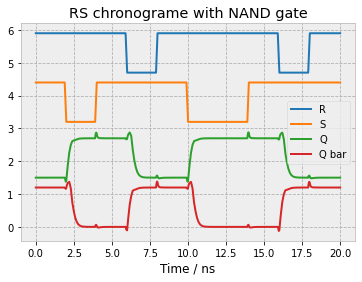

In [7]:
time = analysis.time

plt.figure()
plt.title("RS chronograme with NAND gate")
plt.plot(time*1e9, np.array(analysis["vr"])+4.7, label="R")
plt.plot(time*1e9, np.array(analysis["vs"])+3.2, label="S")
plt.plot(time*1e9, np.array(analysis["q"])+1.5,  label="Q")
plt.plot(time*1e9, np.array(analysis["q_bar"]),  label="Q bar")
plt.xlabel("Time / ns")
plt.legend()
plt.show()

En utilisant, il est possible de voir que les systèmes sont inverser, cela veut dire que pour activé, il faut qu'une valeur passe de 1 à 0. Mais aussi la valeur interdite est la valeur ou $R=0$ et ou $S=1$. Mais sinon, il est possible de retrouver la même table de vérité. Lorsque $S$ passe de 0 à 1 alors la valeur de $Q$ passe de la valeur 0 à 1. Ensuite lorsque $R$ (reset) passe à 0 alors la valeur de $Q$ passe à 0. Si les deux valeurs $S$ et $R$ sont a 1 alors la valeur de Q ne bouge pas.

##### With NOR Gate

In [8]:
class NOR(SubCircuit):
    """
    NOR gate

    External nodes:
        A   : Input
        B   : Input
        Y   : Output
        VDD : Power supply
    """

    # Declare external terminals of the subcircuit
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize a NAND subcircuit.

        Parameters
        ----------
        name : str
            Name of the subcircuit instance
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)
        
        # ============================================================
        # CMOS Logic Core
        # NOR gate implementation
        # ============================================================
        
        # ----------------------------
        # PMOS Pull-Up Network (PUN)
        # PMOS transistors are connected in parallel
        # ----------------------------
        
        self.MOSFET(
            1,
            'inter', 'A', 'VDD', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )
        
        self.MOSFET(
            2,
            'Y', 'B', 'inter', 'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )
        
        # ----------------------------
        # NMOS Pull-Down Network (PDN)
        # NMOS transistors are connected in series
        # ----------------------------
        
        self.MOSFET(
            3,
            'Y', 'A', circuit.gnd, circuit.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )
        
        self.MOSFET(
            4,
            'Y', 'B', circuit.gnd, circuit.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        );

In [9]:
class RS_NOR(SubCircuit):
    """
    RS with NOR gate

    External nodes:
        R     : Input
        S     : Input
        Q     : Output
        Q_bar : Output
        VDD   : Power supply
    """

    # Declare external terminals of the subcircuit
    __nodes__ = ('R', 'S', 'Q', 'Q_bar', 'VDD')

    def __init__(self, name):
        """
        Initialize a RS subcircuit with NAND Gate.

        Parameters
        ----------
        name : str
            Name of the subcircuit instance
        """
        # Initialize the SubCircuit
        super().__init__(name, *self.__nodes__)
        
        self.X('L1', 'NOR', 'R', 'Q',  'Q_bar', 'VDD')
        self.X('L2', 'NOR', 'S',  'Q_bar', 'Q', 'VDD')

In [10]:
# ============================================================
# CMOS RS
# Technology: PTM 65 nm
# ============================================================

# Create a new circuit for each input combination
circuit = Circuit('RS with NAND gate')

# ============================================================
# Model Libraries
# Include NMOS, PMOS transistor models
# Include NAND with transistor models
# Include RS with NAND gate
# ============================================================

# Include transistor models
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# Include internal model
circuit.subcircuit(NOR('NOR'))
circuit.subcircuit(RS_NOR('RS_NOR'))

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

step = 2 @ u_ns

circuit.PieceWiseLinearVoltageSource(
    'R',
    'vr',
    circuit.gnd,
    values=[
        (0.0 @ u_ns,  0 @ u_V),
        (2.0 @ u_ns,  0 @ u_V),
        (4.0 @ u_ns,  0 @ u_V),
        (5.9 @ u_ns,  0 @ u_V),
        (6.0 @ u_ns,  VDD @ u_V),
        (7.9 @ u_ns,  VDD @ u_V),
        (8.0 @ u_ns,  0 @ u_V),
        (10 @ u_ns,   0 @ u_V),
        (12 @ u_ns,   0 @ u_V),
        (14 @ u_ns,   0 @ u_V),
        (15.9 @ u_ns, 0 @ u_V),
        (16 @ u_ns,   VDD @ u_V),
        (17.9 @ u_ns, VDD @ u_V),
        (18 @ u_ns,   0 @ u_V),
    ],
)

circuit.PieceWiseLinearVoltageSource(
    'S',
    'vs',
    circuit.gnd,
    values= [
        (0.0  @ u_ns, 0 @ u_V),
        (1.9  @ u_ns, 0 @ u_V),
        (2.0  @ u_ns, VDD @ u_V),
        (3.9  @ u_ns, VDD @ u_V),
        (4.0  @ u_ns, 0 @ u_V),
        (6.0  @ u_ns, 0 @ u_V),
        (8.0  @ u_ns, 0 @ u_V),
        (9.9 @ u_ns,  0 @ u_V),
        (10  @ u_ns,  VDD @ u_V),
        (12  @ u_ns,  VDD @ u_V),
        (13.9 @ u_ns, VDD @ u_V),
        (14 @ u_ns,   0 @ u_V),
        (16 @ u_ns,   0 @ u_V),
        (18 @ u_ns,   0 @ u_V),
    ],
)

# ===========================================================
# Add RS circuit
# ===========================================================

# RS circuit
circuit.X('X1', 'RS_NOR', 'vr', 'vs', 'q', 'q_bar', 'vdd');

In [11]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)
simulator.initial_condition(
    vs     = VDD @ u_V,  
    vr     = VDD @ u_V,  
    q      = VDD @ u_V,  # V(q) = 1.2 V
    q_bar  = 0   @ u_V,  # V(q_bar) = 0 V
)


# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns,
)

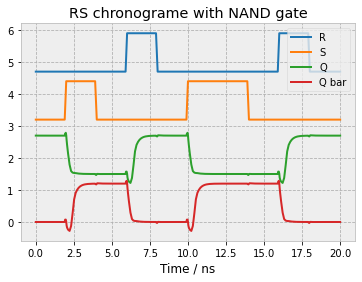

In [12]:
time = analysis.time

plt.figure()
plt.title("RS chronograme with NAND gate")
plt.plot(time*1e9, np.array(analysis["vr"])+4.7, label="R")
plt.plot(time*1e9, np.array(analysis["vs"])+3.2, label="S")
plt.plot(time*1e9, np.array(analysis["q"])+1.5,  label="Q")
plt.plot(time*1e9, np.array(analysis["q_bar"]),  label="Q bar")
plt.xlabel("Time / ns")
plt.legend()
plt.show()

Il est possible de voir que cette fois la valeur correspond parfaitement à la valeur du chronograme présenté dans sur le chronogramme.

### Synthcronous RS Latch

#### Circuit Visualization

Dans cette partie, l'objectif cette fois et de faire la même chose que dans la partie précédente avec des portes logiques, mais cette fois l'objectif est d'avoir une modification de la valeur que sur le front montant de l'horloge. Le montage électronique est quasiment le même qu'avec un montage asynchrone, juste il faut rajouter soit deux portes NAND ou deux portes NOR qui permettent de relier les entrées R et S avec l'entrée H, le montage est représenté sur la [](#RS_synchrone_porte_logique)

```{figure} ./images/RS_synchrone_porte_logique.svg
:name: RS_synchrone_porte_logique
:align: center
:width: 500px

Different logic-gate implementations of an synchronous RS flip-flop
```

#### Simulation

##### Using NAND Gates

In [30]:
# ============================================================
# CMOS RS
# Technology: PTM 65 nm
# ============================================================

# Create a new circuit for each input combination
circuit = Circuit('RS with NAND gate')

# ============================================================
# Model Libraries
# Include NMOS, PMOS transistor models
# Include NAND with transistor models
# Include RS with NAND gate
# ============================================================

# Include transistor models
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# Include internal model
circuit.subcircuit(NAND('NAND'))
circuit.subcircuit(RS_NAND('RS_NAND'))

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

step = 2 @ u_ns

circuit.PulseVoltageSource(
    'H',
    'vh',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width = 0.6 @ u_ns,
    period = 1.4 @ u_ns
)

circuit.PieceWiseLinearVoltageSource(
    'R',
    'vr',
    circuit.gnd,
    values=[
        (0.0 @ u_ns,  0 @ u_V),
        (2.0 @ u_ns,  0 @ u_V),
        (4.0 @ u_ns,  0 @ u_V),
        (5.9 @ u_ns,  0 @ u_V),
        (6.0 @ u_ns,  VDD @ u_V),
        (7.9 @ u_ns,  VDD @ u_V),
        (8.0 @ u_ns,  0 @ u_V),
        (10 @ u_ns,   0 @ u_V),
        (12 @ u_ns,   0 @ u_V),
        (14 @ u_ns,   0 @ u_V),
        (15.9 @ u_ns, 0 @ u_V),
        (16 @ u_ns,   VDD @ u_V),
        (17.9 @ u_ns, VDD @ u_V),
        (18 @ u_ns,   0 @ u_V),
    ],
)

circuit.PieceWiseLinearVoltageSource(
    'S',
    'vs',
    circuit.gnd,
    values= [
        (0.0  @ u_ns, 0 @ u_V),
        (1.9  @ u_ns, 0 @ u_V),
        (2.0  @ u_ns, VDD @ u_V),
        (3.9  @ u_ns, VDD @ u_V),
        (4.0  @ u_ns, 0 @ u_V),
        (6.0  @ u_ns, 0 @ u_V),
        (8.0  @ u_ns, 0 @ u_V),
        (9.9 @ u_ns,  0 @ u_V),
        (10  @ u_ns,  VDD @ u_V),
        (12  @ u_ns,  VDD @ u_V),
        (13.9 @ u_ns, VDD @ u_V),
        (14 @ u_ns,   0 @ u_V),
        (16 @ u_ns,   0 @ u_V),
        (18 @ u_ns,   0 @ u_V),
    ],
)

# ===========================================================
# Add RS circuit
# ===========================================================

# RS circuit
circuit.X('L1', 'NAND', 'vr', 'vh', 'vr_synchro', 'vdd')
circuit.X('L2', 'NAND', 'vs', 'vh', 'vs_synchro', 'vdd')
circuit.X('X1', 'RS_NAND', 'vr_synchro', 'vs_synchro', 'q', 'q_bar', 'vdd');

In [31]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)
simulator.initial_condition(
    vs     = 0 @ u_V,  
    vr     = 0 @ u_V,  
    q      = 0 @ u_V,  # V(q) = 1.2 V
    q_bar  = VDD @ u_V,  # V(q_bar) = 0 V
)


# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns,
)

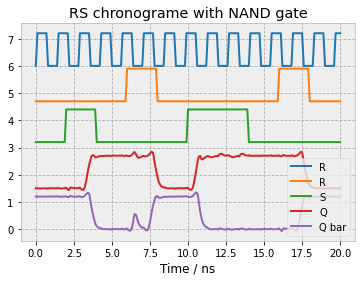

In [32]:
time = analysis.time

plt.figure()
plt.title("RS chronograme with NAND gate")
plt.plot(time*1e9, np.array(analysis["vh"])+6.0, label="R")
plt.plot(time*1e9, np.array(analysis["vr"])+4.7, label="R")
plt.plot(time*1e9, np.array(analysis["vs"])+3.2, label="S")
plt.plot(time*1e9, np.array(analysis["q"])+1.5,  label="Q")
plt.plot(time*1e9, np.array(analysis["q_bar"]),  label="Q bar")
plt.xlabel("Time / ns")
plt.legend()
plt.show()

In [16]:
np.array(analysis["vh"])

array([0.00000000e+00, 1.20000000e-02, 2.40000000e-02, 4.80000000e-02,
       9.60000000e-02, 1.92000000e-01, 3.84000000e-01, 7.68000000e-01,
       1.20000000e+00, 1.20000000e+00, 1.20000000e+00, 1.20000000e+00,
       1.20000000e+00, 1.20000000e+00, 1.20000000e+00, 1.20000000e+00,
       1.20000000e+00, 1.20000000e+00, 1.20000000e+00, 1.20000000e+00,
       1.20000000e+00, 1.20000000e+00, 1.20000000e+00, 1.20000000e+00,
       1.20000000e+00, 1.20000000e+00, 1.20000000e+00, 1.20000000e+00,
       1.10400000e+00, 9.12000000e-01, 5.28000000e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [17]:
analysis.nodes.keys()

dict_keys(['m.xl1.m1#sbody', 'm.xl1.m1#body', 'm.xl1.m1#dbody', 'm.xl1.m1#gate', 'm.xl1.m2#sbody', 'm.xl1.m2#body', 'm.xl1.m2#dbody', 'm.xl1.m2#gate', 'm.xl2.m1#sbody', 'm.xl2.m1#body', 'm.xl2.m1#dbody', 'm.xl2.m1#gate', 'm.xl2.m2#sbody', 'm.xl2.m2#body', 'm.xl2.m2#dbody', 'm.xl2.m2#gate', 'm.xx1.xl1.m1#sbody', 'm.xx1.xl1.m1#body', 'm.xx1.xl1.m1#dbody', 'm.xx1.xl1.m1#gate', 'm.xx1.xl1.m2#sbody', 'm.xx1.xl1.m2#body', 'm.xx1.xl1.m2#dbody', 'm.xx1.xl1.m2#gate', 'm.xx1.xl2.m1#sbody', 'm.xx1.xl2.m1#body', 'm.xx1.xl2.m1#dbody', 'm.xx1.xl2.m1#gate', 'm.xx1.xl2.m2#sbody', 'm.xx1.xl2.m2#body', 'm.xx1.xl2.m2#dbody', 'm.xx1.xl2.m2#gate', 'm.xl1.m3#sbody', 'm.xl1.m3#body', 'm.xl1.m3#dbody', 'm.xl1.m3#gate', 'm.xl1.m4#sbody', 'm.xl1.m4#body', 'm.xl1.m4#dbody', 'm.xl1.m4#gate', 'm.xl2.m3#sbody', 'm.xl2.m3#body', 'm.xl2.m3#dbody', 'm.xl2.m3#gate', 'm.xl2.m4#sbody', 'm.xl2.m4#body', 'm.xl2.m4#dbody', 'm.xl2.m4#gate', 'm.xx1.xl1.m3#sbody', 'm.xx1.xl1.m3#body', 'm.xx1.xl1.m3#dbody', 'm.xx1.xl1.m3#gate',